In [56]:
from Tools.DatasetTools.DatasetOperator import Dataset
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from Tools.DatasetTools import EVCurvesTools as EVtools
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
from importlib.machinery import SourceFileLoader

In [3]:
fullvalidationBS = StructSummaryParser(dataset='validation_data',ForceMakeBS=True).BriefSummary

need to create briefsummary list
reading list of briefsummary


In [4]:
fullvalidationBS['B0']

Fe_pv8Mo_sv22.sigma-BBABB.FM      224.28541
Fe_pv10Mo_sv20.sigma-ABBAB.FM    237.907324
Fe_pv4Mo_sv20.C36-ABBBB.FM       204.470374
Fe_pv3Mo_sv10.mu-ABBBA.FM        402.123952
Fe_pv5Mo_sv24.chi-AABB.FM        216.183583
                                    ...    
Fe_pv3Mo_sv10.mu-ABBBA.NM        240.020984
Fe_pv8Mo_sv22.sigma-BBABB.NM     247.238692
Fe_pv1Mo_sv3.L12-AB3.FM          223.435464
Fe_pv8Mo_sv22.sigma-BBBBA.FM     207.683558
Fe_pv10Mo_sv20.sigma-ABBAB.NM    263.965297
Name: B0, Length: 402, dtype: object

In [5]:
remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"',

In [6]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [7]:
BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.000000,0.000000,FM,C15,0.144169,0.144169,0.144169
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784


In [8]:
validation_samples = fullvalidationBS.index.difference(BS.index)

In [9]:
validation_samples

Index(['Fe_pv10Mo_sv14.C36-ABBAB.FM', 'Fe_pv10Mo_sv14.C36-BABAB.FM',
       'Fe_pv10Mo_sv14.C36-BABBA.FM', 'Fe_pv11Mo_sv2.mu-AABAA.FM',
       'Fe_pv12.C14.FM', 'Fe_pv12Mo_sv12.C36-AAABB.FM',
       'Fe_pv12Mo_sv17.chi-BBAB.FM', 'Fe_pv12Mo_sv41.R-BBABBABBBBB.NM',
       'Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM', 'Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM',
       ...
       'Fe_pv7Mo_sv6.mu-ABAAA.FM', 'Fe_pv8.A15.FM',
       'Fe_pv8Mo_sv16.C36-AABBB.FM', 'Fe_pv8Mo_sv45.R-BABBBABBBBB.NM',
       'Fe_pv8Mo_sv48.P-BBBBBBBBBBAB.NM',
       'Fe_pv8Mo_sv48.delta-BBBBBBBBABBABB.NM', 'Fe_pv9Mo_sv4.mu-AAABB.FM',
       'Mo_sv53.R-Mo.FM', 'Mo_sv56.P.NM', 'Mo_sv56.delta.NM'],
      dtype='object', length=111)

In [10]:
validationBS = fullvalidationBS.loc[validation_samples]

In [11]:
validationBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Fe_pv10Mo_sv14.C36-ABBAB.FM,bulk C36-ABBAB.FM,14.791477 A,-9.413408,194.257707 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,194.257707,14.791477,Fe_pv,Mo_sv,10,14,24
Fe_pv10Mo_sv14.C36-BABAB.FM,bulk C36-BABAB.FM,14.595271 A,-9.414958,420.901429 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,420.901429,14.595271,Fe_pv,Mo_sv,10,14,24
Fe_pv10Mo_sv14.C36-BABBA.FM,bulk C36-BABBA.FM,14.599262 A,-9.464137,249.350538 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,249.350538,14.599262,Fe_pv,Mo_sv,10,14,24
Fe_pv11Mo_sv2.mu-AABAA.FM,bulk mu-AABAA.FM,12.022507 A,-8.459843,-6867.530562 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,-6867.530562,12.022507,Fe_pv,Mo_sv,11,2,13
Fe_pv12.C14.FM,bulk C14.FM,12.119019 A,-8.105991,102.152576 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,102.152576,12.119019,Fe_pv,,12,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv8Mo_sv48.delta-BBBBBBBBABBABB.NM,bulk delta-BBBBBBBBABBABB,15.295075 A,-10.375337,250.595755 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,250.595755,15.295075,Fe_pv,Mo_sv,8,48,56
Fe_pv9Mo_sv4.mu-AAABB.FM,bulk mu-AAABB.FM,12.500300 A,-9.025307,264.090385 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,264.090385,12.5003,Fe_pv,Mo_sv,9,4,13
Mo_sv53.R-Mo.FM,bulk R-Mo.FM,16.315255 A,-10.625316,238.811481 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,238.811481,16.315255,Mo_sv,,53,0,53
Mo_sv56.P.NM,bulk P,16.233090 A,-10.689768,243.233916 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,243.233916,16.23309,Mo_sv,,56,0,56


TODO:
[ ] calculate formation energies for new calculations

In [12]:
validationBS = validationBS[~validationBS.index.str.contains('sigma.[DU]')]

In [13]:
validationBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Fe_pv10Mo_sv14.C36-ABBAB.FM,bulk C36-ABBAB.FM,14.791477 A,-9.413408,194.257707 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,194.257707,14.791477,Fe_pv,Mo_sv,10,14,24
Fe_pv10Mo_sv14.C36-BABAB.FM,bulk C36-BABAB.FM,14.595271 A,-9.414958,420.901429 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,420.901429,14.595271,Fe_pv,Mo_sv,10,14,24
Fe_pv10Mo_sv14.C36-BABBA.FM,bulk C36-BABBA.FM,14.599262 A,-9.464137,249.350538 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,249.350538,14.599262,Fe_pv,Mo_sv,10,14,24
Fe_pv11Mo_sv2.mu-AABAA.FM,bulk mu-AABAA.FM,12.022507 A,-8.459843,-6867.530562 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,-6867.530562,12.022507,Fe_pv,Mo_sv,11,2,13
Fe_pv12.C14.FM,bulk C14.FM,12.119019 A,-8.105991,102.152576 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,102.152576,12.119019,Fe_pv,,12,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv8Mo_sv48.delta-BBBBBBBBABBABB.NM,bulk delta-BBBBBBBBABBABB,15.295075 A,-10.375337,250.595755 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,250.595755,15.295075,Fe_pv,Mo_sv,8,48,56
Fe_pv9Mo_sv4.mu-AAABB.FM,bulk mu-AAABB.FM,12.500300 A,-9.025307,264.090385 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,264.090385,12.5003,Fe_pv,Mo_sv,9,4,13
Mo_sv53.R-Mo.FM,bulk R-Mo.FM,16.315255 A,-10.625316,238.811481 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,238.811481,16.315255,Mo_sv,,53,0,53
Mo_sv56.P.NM,bulk P,16.233090 A,-10.689768,243.233916 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,243.233916,16.23309,Mo_sv,,56,0,56


# Check EVcurves

In [14]:
validation_dataset='validation_data'

In [15]:
fittedcurvesloc = os.path.join(validation_dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(validation_dataset,'evcurves.json' )
goodnessloc = os.path.join(validation_dataset, 'goodness.json')
force = True

In [16]:
EVtools = SourceFileLoader('EVctools', 'Tools/DatasetTools/EVCurvesTools.py').load_module()

In [17]:
test_indexes = validationBS.index[validationBS.index.str.contains('Mo_sv.*P.NM')]

In [18]:
validationBS.loc[test_indexes]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Mo_sv56.P.NM,bulk P,16.233090 A,-10.689768,243.233916 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,243.233916,16.23309,Mo_sv,,56,0,56


In [19]:
if not os.path.exists(fittedcurvesloc) or force:
    if True : #not os.path.exists(evcurvesloc) or force:
        EV = EVtools.Evcurves(Indexes = validationBS.index, atoms=['Fe','Mo'], dataset = validation_dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = validationBS['deltak'], encuts = validationBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = EVtools.get_goodness(EVcurves, r2tol = 1e-6)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = EVtools.invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            if index in R2.keys():
                if key in R2[index].keys():
                    data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    print('B')
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = EVtools.get_key_for_curves(EVcurves, 'r2')
    Goodness = EVtools.get_key_for_curves(EVcurves, 'IsGood')
    Fits = EVtools.get_key_for_curves(EVcurves, 'fit')

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

# Recover Predicted values

([<Figure size 1080x576 with 1 Axes>],
 [<AxesSubplot:title={'center':'Mo_sv56.P.NM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>])

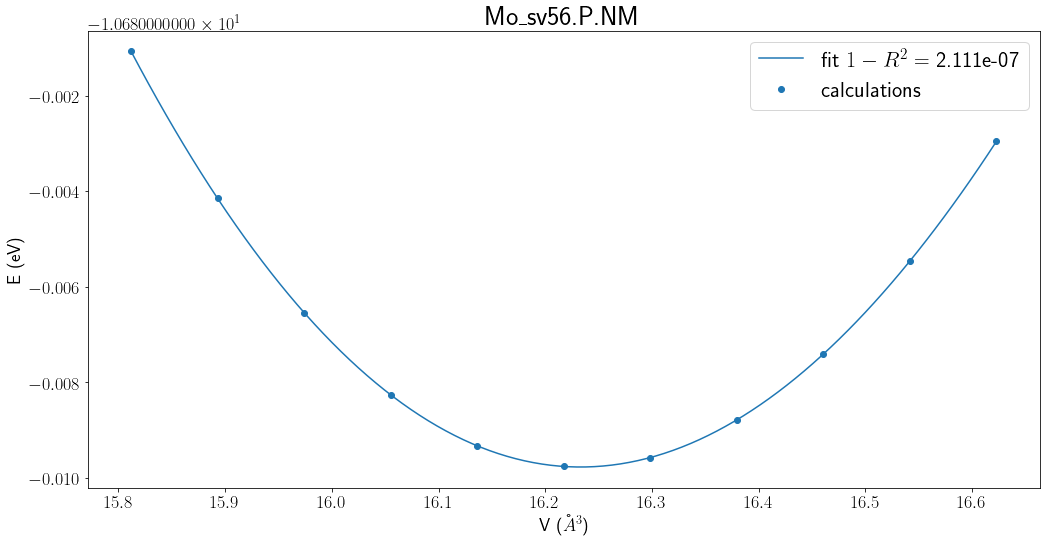

In [20]:
EVtools.plot_curves(EVcurves[test_indexes], Fits[test_indexes], R2[test_indexes])

In [21]:
EVcurves_df = pd.DataFrame.from_dict(EVcurves.to_dict(), orient='index')

In [22]:
empty_curves = EVcurves[EVcurves.map(lambda c: len(c)==0)].index

In [23]:
EVcurves[empty_curves]

Fe_pv10Mo_sv14.C36-ABBAB.FM     {}
Fe_pv10Mo_sv14.C36-BABAB.FM     {}
Fe_pv10Mo_sv14.C36-BABBA.FM     {}
Fe_pv11Mo_sv2.mu-AABAA.FM       {}
Fe_pv12.C14.FM                  {}
Fe_pv12Mo_sv12.C36-AAABB.FM     {}
Fe_pv12Mo_sv17.chi-BBAB.FM      {}
Fe_pv14Mo_sv10.C36-AABAB.FM     {}
Fe_pv14Mo_sv10.C36-AABBA.FM     {}
Fe_pv14Mo_sv10.C36-ABAAB.FM     {}
Fe_pv14Mo_sv10.C36-BAABA.FM     {}
Fe_pv16Mo_sv13.chi-BAAB.FM      {}
Fe_pv17Mo_sv12.chi-AAAB.FM      {}
Fe_pv18Mo_sv6.C36-AAABA.FM      {}
Fe_pv24Mo_sv6.sigma-BBAAA.FM    {}
Fe_pv28Mo_sv1.chi-BAAA.FM       {}
Fe_pv2Mo_sv4.C15-AB2.FM         {}
Fe_pv5Mo_sv8.mu-ABAAB.FM        {}
Fe_pv5Mo_sv8.mu-ABABA.FM        {}
Fe_pv5Mo_sv8.mu-ABBAA.FM        {}
Fe_pv5Mo_sv8.mu-ABBAA.NM        {}
Fe_pv6Mo_sv7.mu-BBAAA.FM        {}
Fe_pv7Mo_sv6.mu-ABAAA.FM        {}
Fe_pv8.A15.FM                   {}
Fe_pv8Mo_sv16.C36-AABBB.FM      {}
Fe_pv9Mo_sv4.mu-AAABB.FM        {}
Mo_sv53.R-Mo.FM                 {}
dtype: object

In [24]:
complete_curves = EVcurves.index.difference(empty_curves)

Only take the validationBS with given EV curves

In [25]:
validationBS = validationBS.loc[complete_curves]
EVcurves = EVcurves[complete_curves]
R2 = R2[complete_curves]
Fits = Fits[complete_curves]

# Get dataframes 

In [26]:
R2_df = pd.DataFrame.from_dict(R2.to_dict(), orient='index')

In [27]:
Fits_df = pd.DataFrame.from_dict(Fits.to_dict(), orient='index')

In [28]:
Better_evcurves = {}

In [29]:
for index, evcurves in EVcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

/tmp/ipykernel_399560/1452277664.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
/tmp/ipykernel_399560/1452277664.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]


In [30]:
Better_evcurves_df = pd.DataFrame.from_dict(Better_evcurves, orient='index')

In [31]:
ev_fit_results_df = pd.DataFrame.from_dict(Better_evcurves_df.ev_fit_results.to_dict(), orient='index')

In [32]:
fit_results = Better_evcurves_df.fit.map( lambda f : {name: val for name, val in zip(['E_murn', 'B_murn', 'Bdev_murn', 'V_murn'], f)})

In [33]:
fit_results_df = pd.DataFrame.from_dict(fit_results.to_dict(), orient='index')

Text(0.5, 1.0, '28 Good Samples')

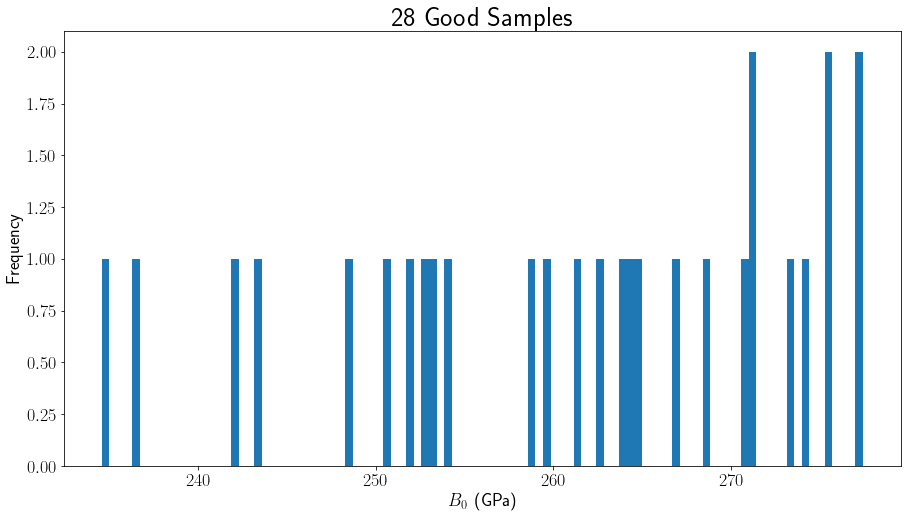

In [34]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [35]:
Better_evcurves_df.shape

(52, 6)

In [36]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [37]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [38]:
indexofbadsamples

Index(['Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM',
       'Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM',
       'Fe_pv19Mo_sv34.R-ABABAABBBBB.NM', 'Fe_pv20Mo_sv33.R-BAAABABBBBB.NM',
       'Fe_pv24Mo_sv32.P-AAABBBBABBAB.NM', 'Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM',
       'Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM', 'Fe_pv32Mo_sv24.P-AAABBBAAABAB.NM',
       'Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM',
       'Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM', 'Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM',
       'Fe_pv40Mo_sv12.M-AAAAAAABABB.NM',
       'Fe_pv40Mo_sv16.delta-AAAAAABBABAAAB.NM',
       'Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM', 'Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM',
       'Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM',
       'Fe_pv48Mo_sv8.delta-AAAAAABAAAAABA.NM',
       'Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM', 'Fe_pv52Mo_sv4.P-AAAABAAAAAAA.NM',
       'Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM', 'Fe_pv56.P.NM',
       'Fe_pv56.delta.NM', 'Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM',
       'Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM'],
      dtype='object')

In [39]:
Better_evcurves_df.index.difference(validationBS.index)

Index([], dtype='object')

Text(0.5, 1.0, '28 Good Samples')

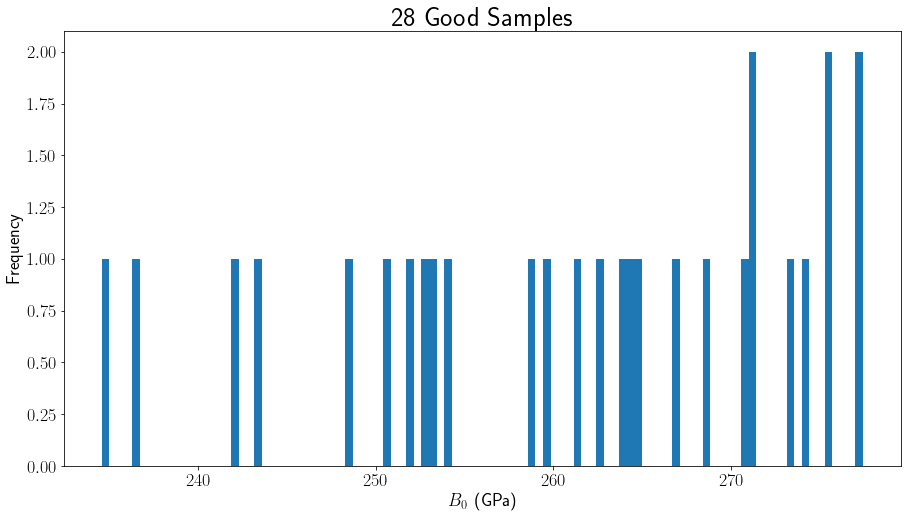

In [40]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [41]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [42]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [43]:
Better_evcurves_df.index.difference(validationBS.index)

Index([], dtype='object')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


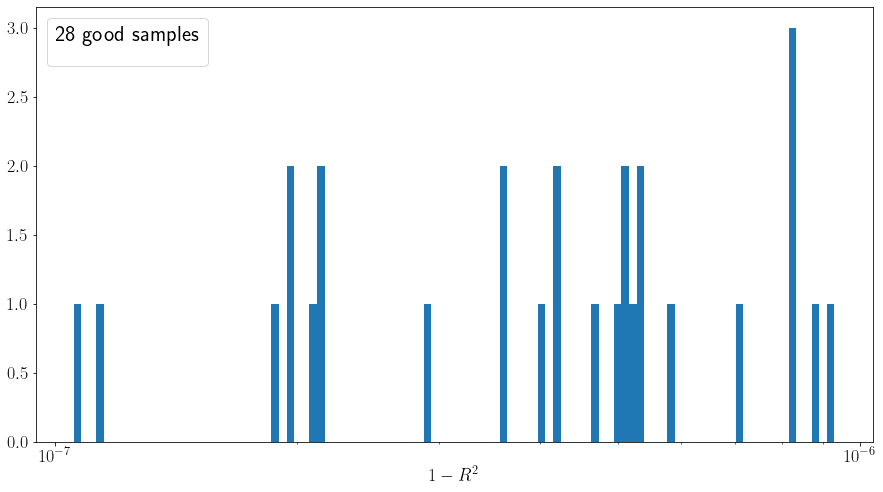

In [44]:
hist, bins = np.histogram(1-Better_evcurves_df.r2[indexofgoodsamples], bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
fig, ax = plt.subplots()
ax.hist(1-Better_evcurves_df.r2[indexofgoodsamples], bins=logbins)
Better_evcurves_df.r2[indexofgoodsamples]
ax.set_xscale('log')
xlabel = ax.set_xlabel('$1-R^2$')
NGOOD = len(indexofgoodsamples)
ax.legend(title=f'{NGOOD} good samples')

# Differences between fits and available data for bad samples

In [45]:
diff_fit_to_dataset = ((validationBS.B0[indexofbadsamples] - fit_results_df.B_murn[indexofbadsamples])/fit_results_df.B_murn[indexofbadsamples]).abs().to_frame().rename(columns={0: 'B0'})

In [46]:
diff_fit_to_dataset['E0'] = ((validationBS.E0[indexofbadsamples] - fit_results_df.E_murn[indexofbadsamples])/fit_results_df.E_murn[indexofbadsamples]).abs().dropna()

In [47]:
diff_fit_to_dataset['V0'] = ((validationBS.V0[indexofbadsamples] - fit_results_df.V_murn[indexofbadsamples])/fit_results_df.V_murn[indexofbadsamples]).abs().dropna()

Text(0.5, 0, '$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

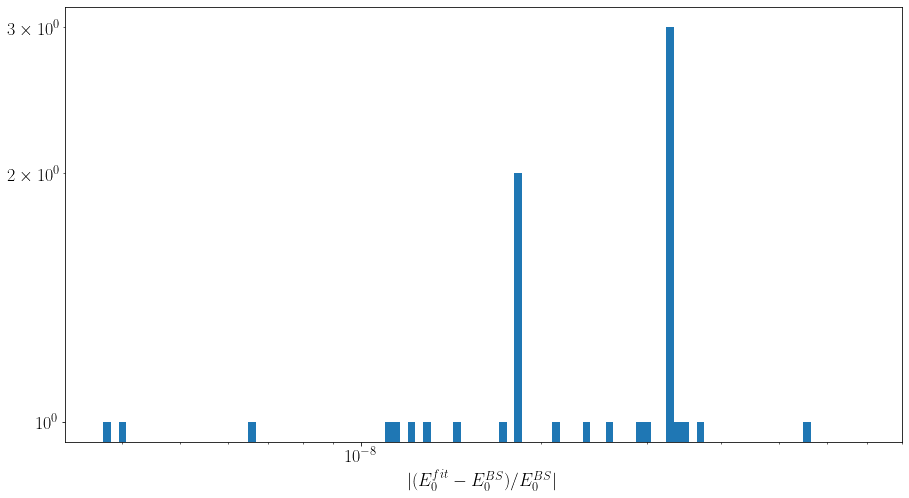

In [48]:
large_diff_E0 = diff_fit_to_dataset.query('E0 > 1e-5').index
fig, ax = plt.subplots()
hist, bins = np.histogram(diff_fit_to_dataset.E0, bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
loghist = plt.hist(diff_fit_to_dataset.E0, bins=logbins)
fig = plt.xscale('log')
fig = plt.yscale('log')
for index in large_diff_E0:
    x = diff_fit_to_dataset.E0[index]
    y = 1
    ax.annotate(index, (x, y), rotation='90')
plt.xlabel(r'$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

# Try to correct the bad fits by removing points 

In [49]:
from importlib.machinery import SourceFileLoader

In [50]:
len(validationBS)

52

In [51]:
len(indexofgoodsamples)

28

In [52]:
len(indexofbadsamples)

24

In [58]:
GoodBS = validationBS.loc[indexofgoodsamples]

In [59]:
from importlib.machinery import SourceFileLoader
find_the_good_curve_inside = SourceFileLoader('find_the_good_curve_inside','Tools/DatasetTools/EVCurvesTools.py').load_module().find_the_good_curve_inside
is_common_sense_evcurve = SourceFileLoader('is_common_sense_evcurve','Tools/DatasetTools/EVCurvesTools.py').load_module().is_common_sense_evcurve
ev_per_angstrom3_to_GPA = 160.21

doexit = False

fixedevcurves = pd.Series([], name='FixedEVcurves')
fixedr2 = pd.Series([], name='FixedR2')
fixedfit = pd.Series([], name='Fixedfit')
tol = 1e-6
now_is_good = []
common_sense_evcurve = []
progress = tqdm(EVcurves[indexofbadsamples].items(), total = len(indexofbadsamples))
for index, paramcurve in progress:
    if index in fixedevcurves.keys():
        continue
    progress.set_description('index')
    if index in GoodBS.index:
        continue
    for paramspec, curvedata in paramcurve.items():
        r2, params_onreduced, reducedv, reducede = find_the_good_curve_inside(curvedata, tol=tol, reset_guess_params = True)
        common_sense_evcurve.append( is_common_sense_evcurve(reducedv, reducede, params_onreduced, unitsofb0='GPa'))
        now_is_good.append( (r2>1-tol) & common_sense_evcurve )
        now_is_good.append( (r2>1-tol) & common_sense_evcurve[-1] )
        progress.set_postfix_str(f'{index}, 1-r2 = {1-r2:.2e}, B0={params_onreduced[1]}, now is good = {now_is_good[-1]}')
        if params_onreduced[1] < 0 and now_is_good:
            raise ValueError('B0 is negative on '+index)
        fixedevcurves[index] = {
            paramspec: {
                'evcurve' :{ 'V' : reducedv , 'E': reducede },
                'ev_fit_results' :  {'E_murn': params_onreduced[0], 'V_murn' : params_onreduced[-1], 'B_murn': params_onreduced[1], 'Bdev_murn' : params_onreduced[2]},
                'r2' : r2,
                'IsGood' : now_is_good[-1],
                'fit': params_onreduced,
                'calc_param' : paramspec
            }
        }

  0%|          | 0/24 [00:00<?, ?it/s]

/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [61]:
fixedevcurves

Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv24Mo_sv32.P-AAABBBBABBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv32Mo_sv24.P-AAABBBAAABAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurv

In [62]:
fixedevcurves_df = pd.DataFrame.from_dict(fixedevcurves.to_dict(), orient='index')

In [63]:
fixedevcurves_df.shape

(24, 1)

In [64]:
Better_fixedevcurves = {}

In [65]:
for index, evcurves in fixedevcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_fixedevcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

/tmp/ipykernel_399560/667138312.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
/tmp/ipykernel_399560/667138312.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Better_fixedevcurves[index] = nonan_evcurves[nonan_evcurves.index][0]


In [66]:
Better_fixedevcurves_df = pd.DataFrame.from_dict(Better_fixedevcurves, orient='index')

In [67]:
fixedR2 = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedR2[index] = {paramspec: curvedata['r2']}

In [68]:
fixedFits = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedFits[index] = {paramspec: curvedata['fit']}

In [69]:
fixed_ev_fit_results = {} #pd.DataFrame([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixed_ev_fit_results[index] = pd.Series(curvedata['ev_fit_results'])
fixed_ev_fit_results_df = pd.DataFrame.from_dict(fixed_ev_fit_results, orient='index')

In [70]:
indexoffixedgoodsamples = Better_fixedevcurves_df.query('IsGood == True').index

In [71]:
indexoffixedbadsamples = Better_fixedevcurves_df.index.difference(indexoffixedgoodsamples)

In [72]:
indexoffixedbadsamples

Index([], dtype='object')

In [86]:
len(indexoffixedgoodsamples) + len(indexofgoodsamples)#+len(indexoffixedbadsamples)

52

In [87]:
finalindexofsamples = indexofgoodsamples.append(indexoffixedgoodsamples)

In [88]:
finalindexofsamples

Index(['Fe_pv12Mo_sv41.R-BBABBABBBBB.NM', 'Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM',
       'Fe_pv13Mo_sv40.R-ABABBABBBBB.NM', 'Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM',
       'Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM', 'Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM',
       'Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM', 'Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM',
       'Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM',
       'Fe_pv28Mo_sv28.P-AAABBBAABBAB.NM',
       'Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM',
       'Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM',
       'Fe_pv32Mo_sv24.delta-AAAAAABBABBABB.NM',
       'Fe_pv33Mo_sv20.R-AAAAAABBABB.NM', 'Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM',
       'Fe_pv36Mo_sv20.delta-AAAAAABAABBABB.NM',
       'Fe_pv39Mo_sv14.R-AAAAAAABABB.NM', 'Fe_pv40Mo_sv16.P-AAABBBAAABAA.NM',
       'Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM', 'Fe_pv47Mo_sv6.R-AAAAAABBAAA.NM',
       'Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM',
       'Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM',
       'Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM', 'Fe_pv8Mo_sv45.R-BABBBABBBBB.NM',
       'Fe_pv8M

In [89]:
fixedValidationBS = validationBS.loc[finalindexofsamples]

# Fixed quantities

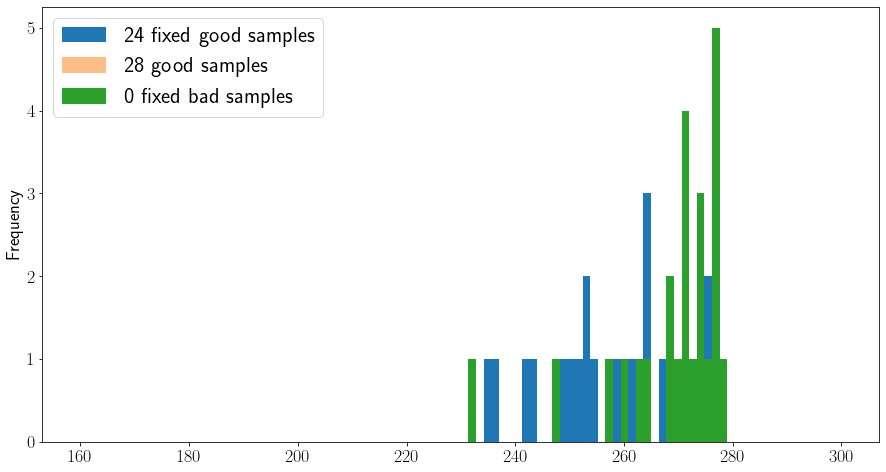

In [90]:
thebins = np.linspace(160, 300, 101)
ax = ev_fit_results_df.B_murn[indexofgoodsamples].plot.hist(bins=thebins)
fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax = ax, alpha=0.5, )
fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax=ax)
ax.legend([f'{len(indexoffixedgoodsamples)} fixed good samples', f'{len(indexofgoodsamples)} good samples', f'{len(indexoffixedbadsamples)} fixed bad samples'])

# redefine the new good BS

but now I need to correct the E0, B0 and V0 to the results of the fix !

In [92]:
fixedValidationBS['E0'].dropna()

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM          -10.155735
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM           -9.952566
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM          -10.107377
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM         -10.077997
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM           -9.605003
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM           -9.818704
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM          -9.926956
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM           -9.673818
Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM    -9.709519
Fe_pv28Mo_sv28.P-AAABBBAABBAB.NM          -9.536149
Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM    -9.349096
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM           -9.291793
Fe_pv32Mo_sv24.delta-AAAAAABBABBABB.NM    -9.211688
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM           -9.223979
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM           -9.028283
Fe_pv36Mo_sv20.delta-AAAAAABAABBABB.NM    -9.034881
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM           -8.899309
Fe_pv40Mo_sv16.P-AAABBBAAABAA.NM          -8.899489
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM            -8.365961
Fe_pv47Mo_sv

In [94]:
fixedValidationBS.loc[indexoffixedgoodsamples,'E0'] = fixed_ev_fit_results_df['E_murn'][indexoffixedgoodsamples]
fixedValidationBS.loc[indexoffixedgoodsamples,'V0'] = fixed_ev_fit_results_df['V_murn'][indexoffixedgoodsamples]
fixedValidationBS.loc[indexoffixedgoodsamples,'B0'] = fixed_ev_fit_results_df['B_murn'][indexoffixedgoodsamples]
fixedValidationBS.dropna().describe()

,nelem,num_atom_A,num_atom_B,num_atoms
count,52.000000,52.000000,52.000000,52.000000
mean,1.923077,32.192308,22.076923,54.269231
std,0.269069,15.452696,15.330152,1.716305
min,1.000000,6.000000,0.000000,52.000000
25%,2.000000,19.750000,7.500000,53.000000
50%,2.000000,32.000000,20.500000,53.000000
75%,2.000000,47.000000,34.250000,56.000000
max,2.000000,56.000000,48.000000,56.000000


In [95]:
fixedValidationBS.shape

(52, 17)

In [109]:
import re

In [126]:
def get_phase_from_index(theindex):
    phaseconfig = theindex.split('.')[1]
    phase = phaseconfig.split('-')[0]
    return phase

In [130]:
fixedValidationBS['Phase'] = fixedValidationBS.index.map(get_phase_from_index)

In [131]:
fixedValidationBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Phase
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM,bulk R-BBABBABBBBB,14.799765 A,-10.155735,252.670511 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,252.670511,14.799765,Fe_pv,Mo_sv,12,41,53,R
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM,bulk R-BBBBBBAABBB,15.127063 A,-9.952566,236.397567 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,236.397567,15.127063,Fe_pv,Mo_sv,12,41,53,R
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM,bulk R-ABABBABBBBB,14.682019 A,-10.107377,253.012900 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,253.0129,14.682019,Fe_pv,Mo_sv,13,40,53,R
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM,bulk P-BBABBBBABBAB,14.345515 A,-10.077997,259.592633 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,259.592633,14.345515,Fe_pv,Mo_sv,16,40,56,P
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM,bulk R-BBBBBBAAABB,14.604681 A,-9.605003,234.546435 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,234.546435,14.604681,Fe_pv,Mo_sv,18,35,53,R
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM,bulk M-ABBAABBBBBB,13.775506 A,-9.818704,263.925712 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,263.925712,13.775506,Fe_pv,Mo_sv,20,32,52,M
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM,bulk P-BAABBBBABBAB,13.873401 A,-9.926956,264.579590 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,264.57959,13.873401,Fe_pv,Mo_sv,20,36,56,P
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM,bulk M-BAAAABBBBBB,13.239078 A,-9.673818,271.174559 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,271.174559,13.239078,Fe_pv,Mo_sv,24,28,52,M
Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM,bulk delta-BBBBBABBABAAAA,13.503410 A,-9.709519,264.367738 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,264.367738,13.50341,Fe_pv,Mo_sv,24,32,56,delta
Fe_pv28Mo_sv28.P-AAABBBAABBAB.NM,bulk P-AAABBBAABBAB,13.055749 A,-9.536149,268.657325 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,268.657325,13.055749,Fe_pv,Mo_sv,28,28,56,P
